In [666]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

In [667]:
df_raw = pd.read_csv("data/Symbol_Info_extended.csv")

df = df_raw.copy()

df = df[
    (df["market_cap"] > 0) &
    (df["total_revenue"] > 0)
].copy()

df.loc[df['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
df.loc[df['price_to_book'] <= 0, 'price_to_book'] = np.nan

df["market_cap_b"] = df["market_cap"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100
df["dividend_yield_pct"] = df["dividend_yield"]

df = df.replace([np.inf, -np.inf], np.nan)

print("Cleaned investment:", df.shape) 

df[['symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap', 
    'return_on_assets', 'return_on_equity', 'profit_margins',             
    'pe_trailing', 'price_to_book', 'revenue_growth',                      
    'debt_to_equity', 'free_cashflow']]


Cleaned investment: (2872, 31)


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,4.704534,0.070,51.390,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,2.759500,-0.052,37.019,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,NaN,0.108,NaN,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,32.910347,0.393,346.579,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,12.958943,0.514,25.356,-4.455833e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3063,ZTS,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,United States,3.409163e+10,0.15525,0.67748,0.28035,13.331148,10.373772,0.029,286.236,1.780875e+09
3064,ZUMZ,Zumiez Inc.,Consumer Cyclical,Apparel Retail,United States,4.132746e+08,0.02193,0.04095,0.01440,30.705130,1.127961,0.044,61.467,4.482962e+07
3066,ZVRA,"Zevra Therapeutics, Inc.",Healthcare,Biotechnology,United States,5.929243e+08,0.02759,1.00652,1.01577,4.990050,3.687500,0.775,0.557,2.585225e+07
3067,ZWS,Zurn Elkay Water Solutions Corporation,Industrials,Pollution & Treatment Controls,United States,8.042031e+09,0.07201,0.13332,0.12258,39.024390,4.989605,0.114,34.366,2.762250e+08


 SELECTED COMPANY 
Name: The Bank of Nova Scotia | Symbol: BNS | Country: Canada
Industry: Banks - Diversified | Market Cap: 98,243,772,416.00



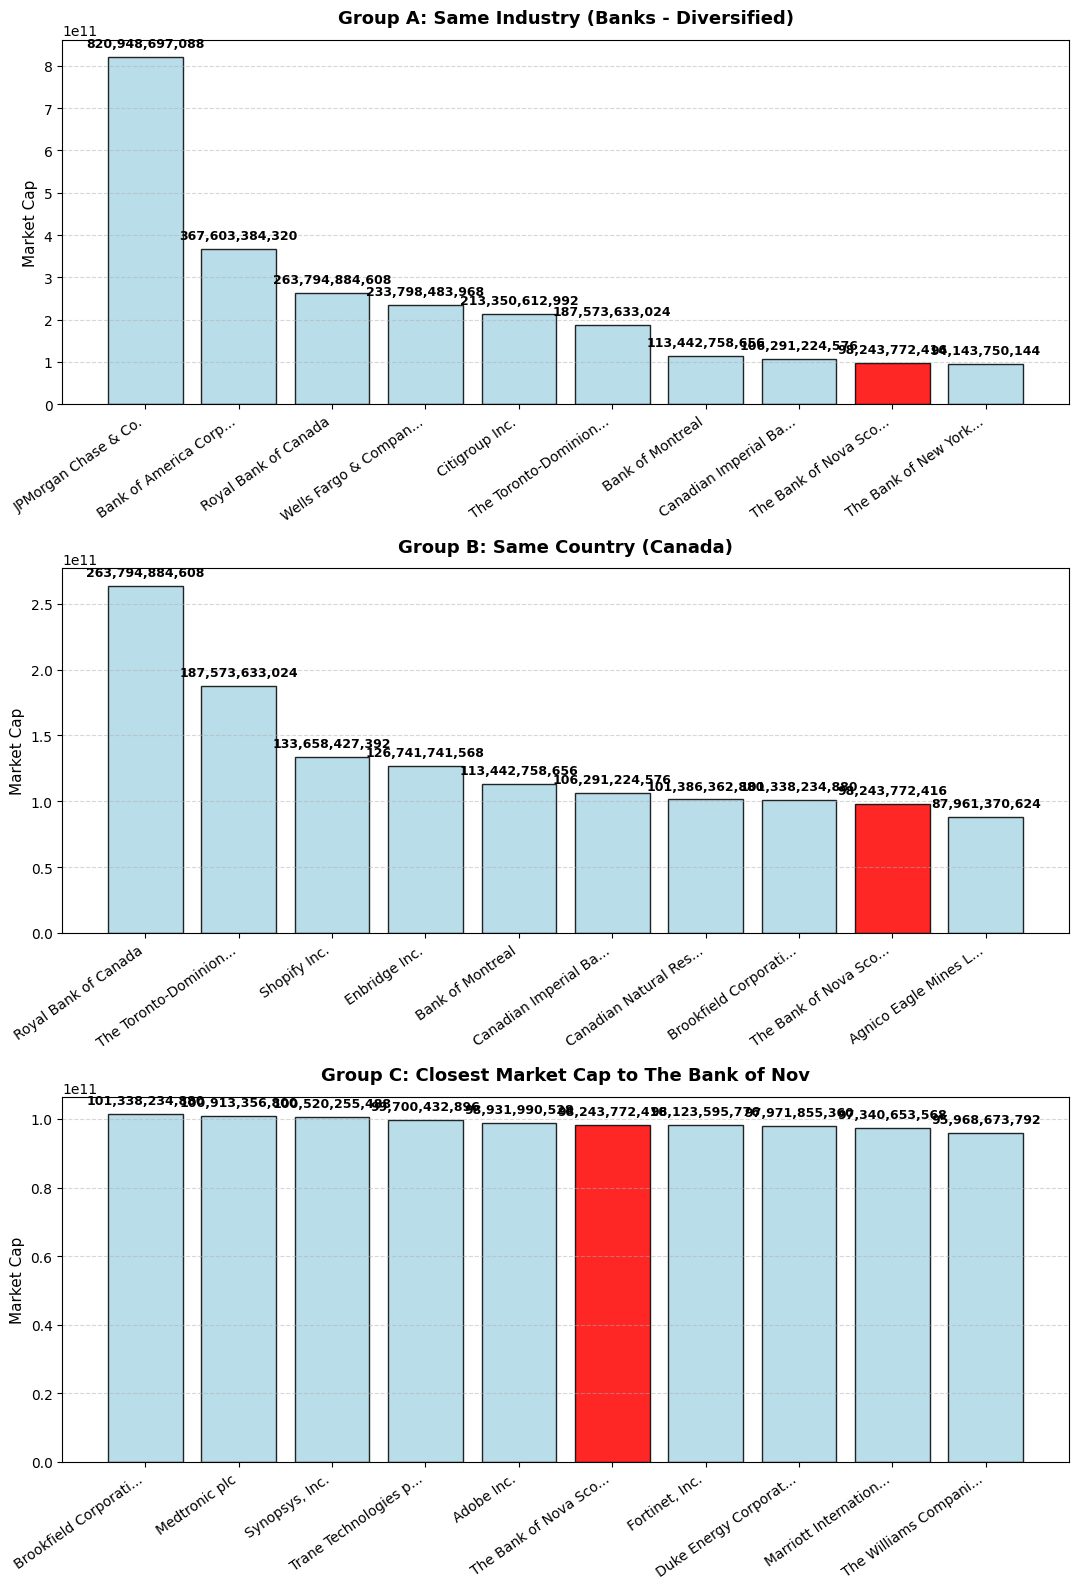

In [668]:
canada_companies = df[df['country'] == 'Canada'] 
if canada_companies.empty:
    raise ValueError("Non ci sono aziende con country='Canada' nel DataFrame!")

selected_company = canada_companies[canada_companies['company_name'] == 'The Bank of Nova Scotia'].iloc[0]

selected_name = selected_company['company_name']
selected_industry = selected_company['industry']
selected_country = selected_company['country'] 
selected_marketcap = selected_company['market_cap']

print(f" SELECTED COMPANY ")
print(f"Name: {selected_name} | Symbol: {selected_company['symbol']} | Country: {selected_country}")
print(f"Industry: {selected_industry} | Market Cap: {selected_marketcap:,.2f}\n")


group_a_all = df[df['industry'] == selected_industry].sort_values(by='market_cap', ascending=False)
group_a_top10 = group_a_all.head(10)

if selected_name not in group_a_top10['company_name'].values:
    group_a = pd.concat([group_a_top10, pd.DataFrame([selected_company])])
else:
    group_a = group_a_top10
group_a = group_a.sort_values(by='market_cap', ascending=False)



group_b_all = df[df['country'] == selected_country].sort_values(by='market_cap', ascending=False)
group_b_top10 = group_b_all.head(10)

if selected_name not in group_b_top10['company_name'].values:
    group_b = pd.concat([group_b_top10, pd.DataFrame([selected_company])])
else:
    group_b = group_b_top10
group_b = group_b.sort_values(by='market_cap', ascending=False)


group_c_c = df.copy()
group_c_c['market_cap_diff'] = (group_c_c['market_cap'] - selected_marketcap).abs()
group_c = group_c_c.sort_values(by='market_cap_diff').head(10).sort_values(by='market_cap', ascending=False)


fig, axes = plt.subplots(3, 1, figsize=(11, 16))

def plot_group(ax, group_df, title):
    colors = ['red' if x == selected_name else 'lightblue' for x in group_df['company_name']]
    
    bars = ax.bar(group_df['company_name'], group_df['market_cap'], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Market Cap', fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in group_df['company_name']]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    for bar in bars:
        yval = bar.get_height()
        offset = group_df['market_cap'].max() * 0.02 
        ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{int(yval):,}", 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plot_group(axes[0], group_a, f"Group A: Same Industry ({selected_industry})")
plot_group(axes[1], group_b, f"Group B: Same Country ({selected_country})")
plot_group(axes[2], group_c, f"Group C: Closest Market Cap to {selected_name[:15]}")

plt.tight_layout()
plt.show()

the chosen company is The Bank of Nova Scotia.
ho scelto questa azienda perchè nonostante abbia un market cap relativamente basso, 

In [669]:
metrics = ['profit_margins', 'return_on_equity']

for metric in metrics:
    df[metric] = pd.to_numeric(df[metric], errors='coerce')
    df[metric] = df[metric].replace([np.inf, -np.inf], np.nan)

df_clean_margins = df.dropna(subset=['profit_margins']).copy()

df_clean_roe = df.dropna(subset=['return_on_equity']).copy()

print("--- RECAP PULIZIA DATI ---")
print(f"Righe nel DataFrame originale: {len(df)}")
print(f"Righe con 'profit_margins' valido: {len(df_clean_margins)}")
print(f"Righe con 'return_on_equity' valido: {len(df_clean_roe)}")


--- RECAP PULIZIA DATI ---
Righe nel DataFrame originale: 2872
Righe con 'profit_margins' valido: 2872
Righe con 'return_on_equity' valido: 2712


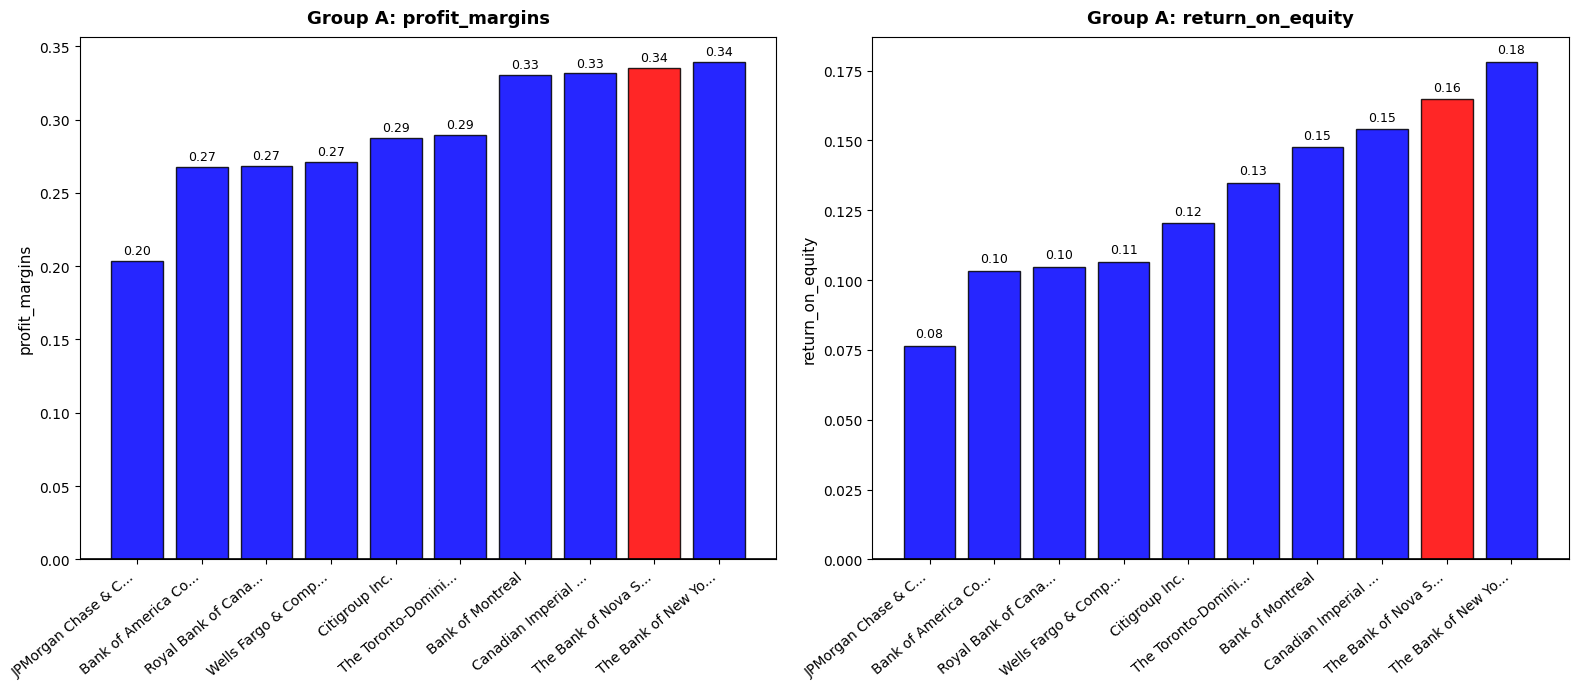

In [671]:
metrics = ['profit_margins', 'return_on_equity']

group_a_all = df[df['industry'] == selected_industry].sort_values(by='market_cap', ascending=False)
group_a_top10 = group_a_all.head(10)

if selected_name not in group_a_top10['company_name'].values:
    group_a = pd.concat([group_a_top10, pd.DataFrame([selected_company])])
else:
    group_a = group_a_top10
group_a = group_a.sort_values(by='market_cap', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

company_names = group_a['company_name'].astype(str).tolist()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    colors = ['red' if name == str(selected_name) else 'blue' for name in company_names]
    group_a_sorted_by_metric = group_a.sort_values(by=metric, ascending=True)

    bars = ax.bar(company_names, group_a_sorted_by_metric[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(f"Group A: {metric}", fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(metric, fontsize=11)
    
    labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    
    ax.axhline(0, color='black', linewidth=1.2)
    
    valid_vals = group_a_sorted_by_metric[metric].dropna()
    offset = (valid_vals.max() - valid_vals.min()) * 0.02 if not valid_vals.empty else 0.05
    if offset == 0 or pd.isna(offset): 
        offset = 0.05
        
    for bar in bars:
        yval = bar.get_height()
        
        if pd.isna(yval):
            continue
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{yval:.2f}", 
                    ha='center', va='bottom', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, f"{yval:.2f}", 
                    ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

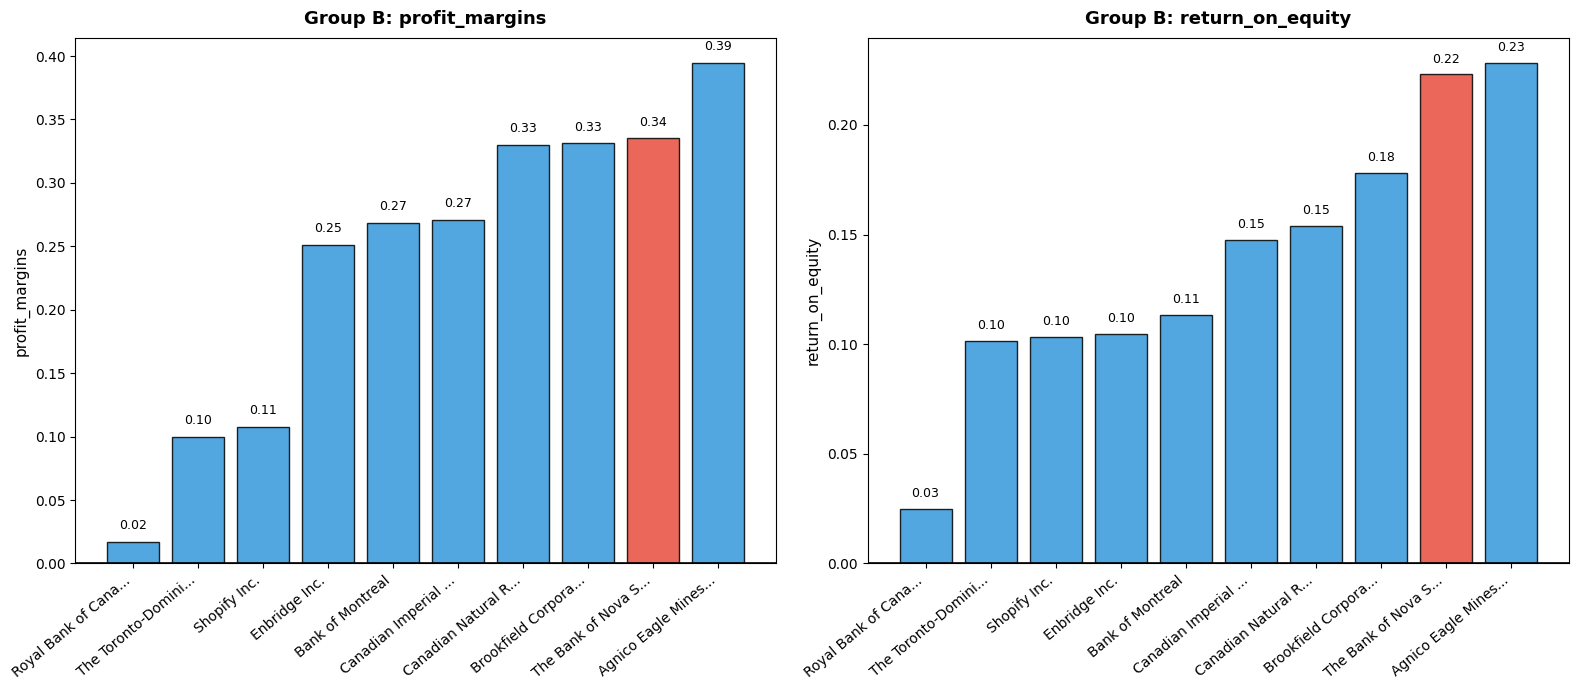

In [672]:
metrics = ['profit_margins', 'return_on_equity']

group_b_all = df[df['country'] == selected_country].sort_values(by='market_cap', ascending=False)
group_b_top10 = group_b_all.head(10)

if selected_name not in group_b_top10['company_name'].values:
    group_b = pd.concat([group_b_top10, pd.DataFrame([selected_company])])
else:
    group_b = group_b_top10
group_b = group_b.sort_values(by='market_cap', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

company_names = group_b['company_name'].astype(str).tolist()

for i, metric in enumerate(metrics):
    ax = axes[i]

    group_b_sorted_by_metric = group_b.sort_values(by=metric, ascending=True)
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, group_b_sorted_by_metric[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(f"Group B: {metric}", fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(metric, fontsize=11)
    
    labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    
    ax.axhline(0, color='black', linewidth=1.2)
    
    valid_vals = group_b_sorted_by_metric[metric].dropna()
    offset = (valid_vals.max() - valid_vals.min()) * 0.02 if not valid_vals.empty else 0.05
    if offset == 0 or pd.isna(offset): 
        offset = 0.05
        
    for bar in bars:
        yval = bar.get_height()
        
        if pd.isna(yval):
            continue
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{yval:.2f}", 
                    ha='center', va='bottom', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, f"{yval:.2f}", 
                    ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

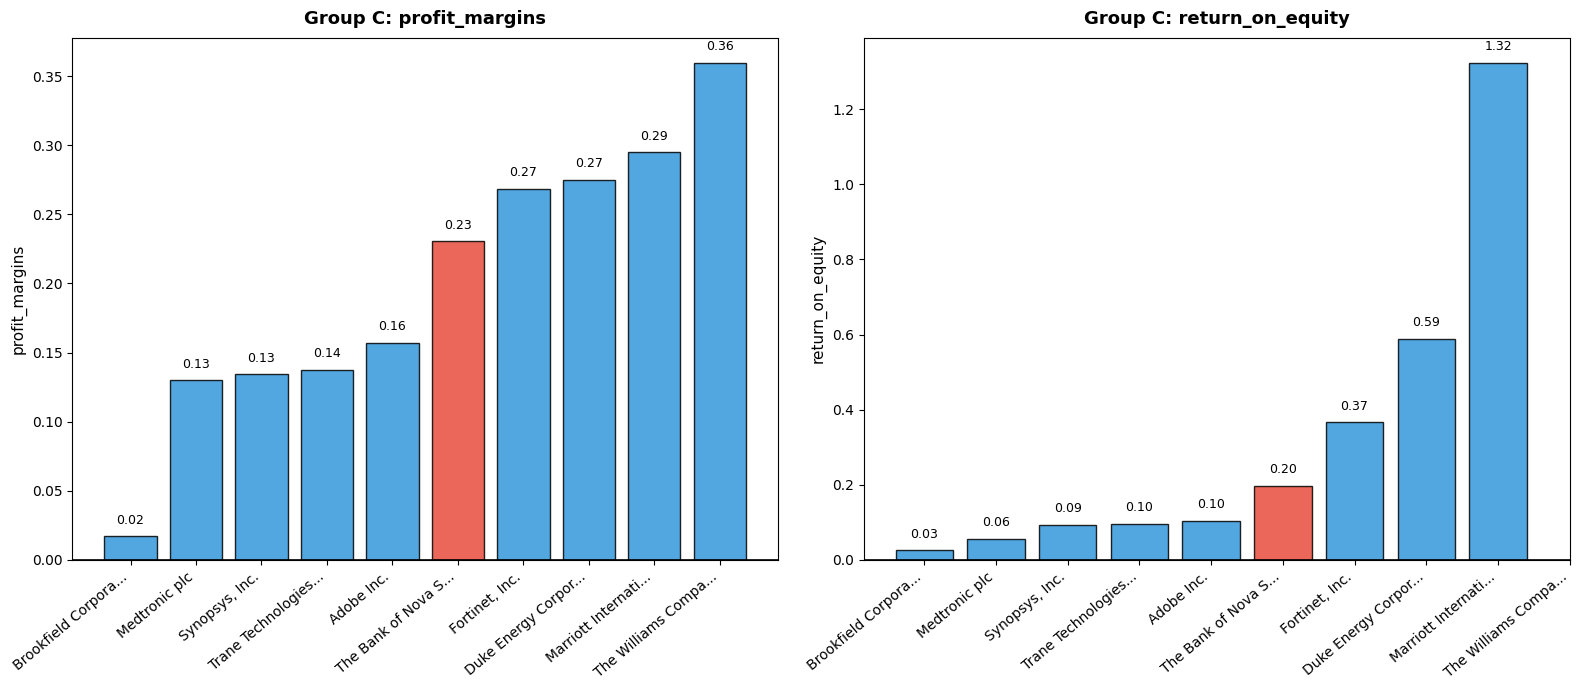

In [673]:
metrics = ['profit_margins', 'return_on_equity']

df_c = df.copy()
df_c['market_cap_diff'] = (df_c['market_cap'] - selected_marketcap).abs()
group_c = df_c.sort_values(by='market_cap_diff').head(10).sort_values(by='market_cap', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

company_names = group_c['company_name'].astype(str).tolist()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    group_c_sorted_by_metric = group_c.sort_values(by=metric, ascending=True)

    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, group_c_sorted_by_metric[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(f"Group C: {metric}", fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(metric, fontsize=11)
    
    labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    
    ax.axhline(0, color='black', linewidth=1.2)
    
    valid_vals = group_c_sorted_by_metric[metric].dropna()
    offset = (valid_vals.max() - valid_vals.min()) * 0.02 if not valid_vals.empty else 0.05
    if offset == 0 or pd.isna(offset): 
        offset = 0.05
        
    # Aggiungo le etichette con i valori numerici
    for bar in bars:
        yval = bar.get_height()
        
        # Se la metrica è NaN, non stampo nulla ed evito errori visivi
        if pd.isna(yval):
            continue
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{yval:.2f}", 
                    ha='center', va='bottom', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, f"{yval:.2f}", 
                    ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

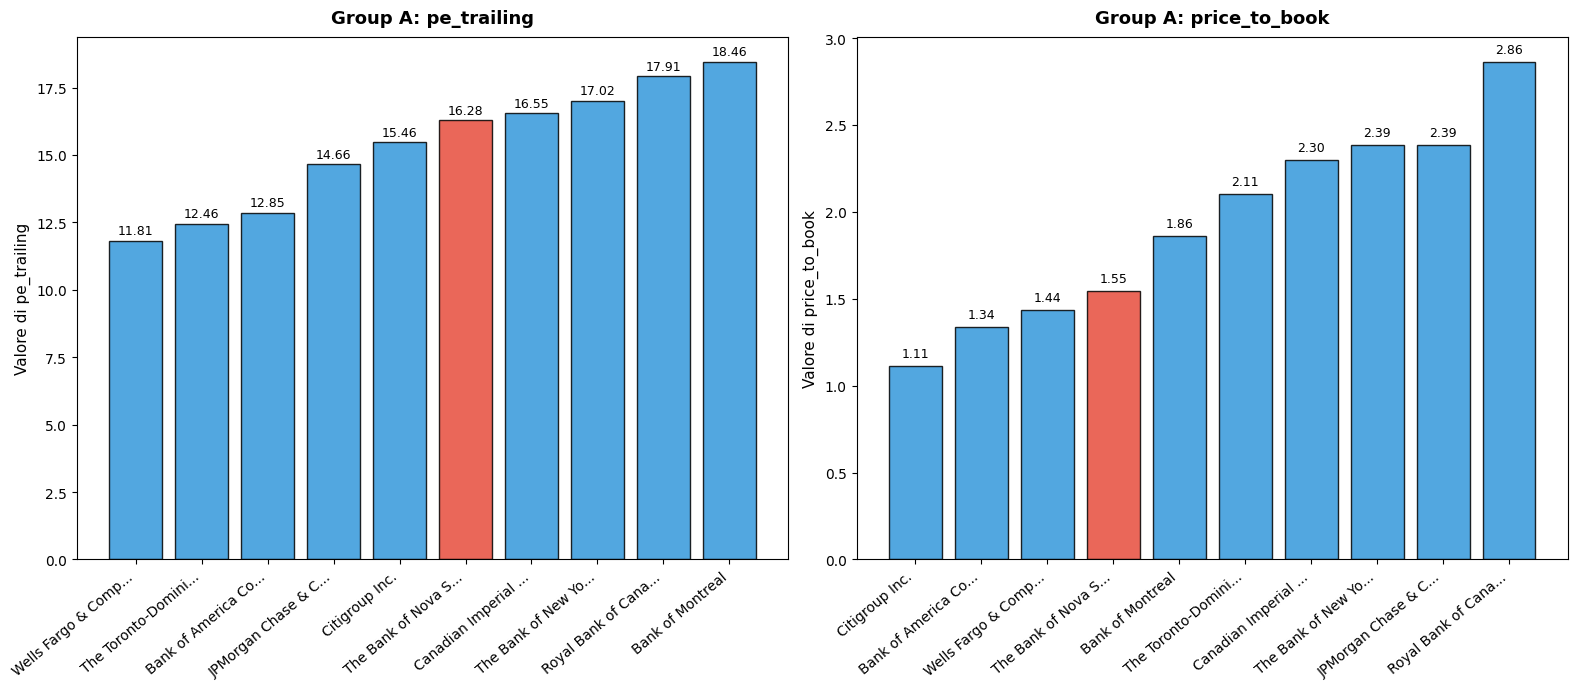

In [674]:

metrics = ['pe_trailing', 'price_to_book']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    valid_df = group_a.copy()
    
    valid_df[metric] = pd.to_numeric(valid_df[metric], errors='coerce')
    
    valid_df.loc[valid_df[metric] <= 0, metric] = np.nan
    
    valid_df = valid_df.dropna(subset=[metric])
    
    valid_df = valid_df.sort_values(by=metric, ascending=True)
    
    if valid_df.empty:
        ax.set_title(f"Group A: {metric}\n(Nessun dato valido > 0)")
        ax.axis('off')
        continue
        
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(f"Group A: {metric}", fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(f"Valore di {metric}", fontsize=11)
    
    labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.5
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
        ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{yval:.2f}", 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

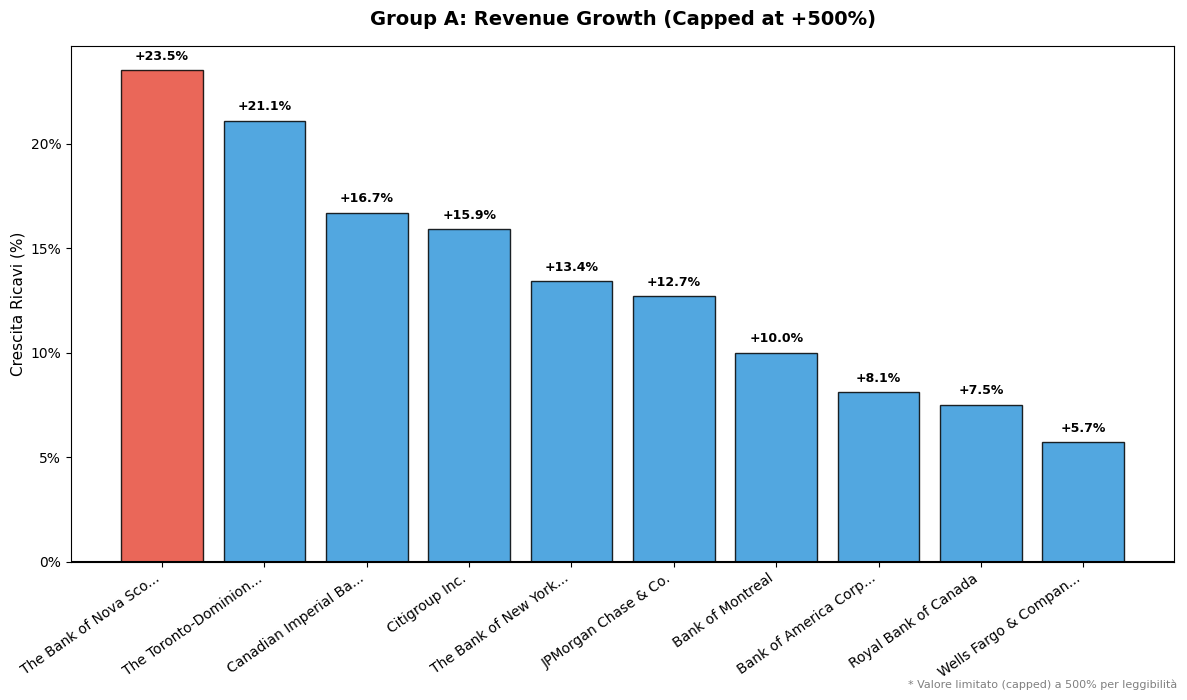

In [675]:

metric = 'revenue_growth'

cap_upper = 5.0  
cap_lower = -1.0
group_a[metric] = group_a[metric].clip(lower=cap_lower, upper=cap_upper)

valid_df = group_a.sort_values(by=metric, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

if valid_df.empty:
    ax.set_title(f"Group A: {metric}\n(Nessun dato valido)")
    ax.axis('off')
else:
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title("Group A: Revenue Growth (Capped at +500%)", fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel("Crescita Ricavi (%)", fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.axhline(0, color='black', linewidth=1.5)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.05
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        label_str = f"+{yval:.1%}" if yval > 0 else f"{yval:.1%}"
        
        if yval == cap_upper:
            label_str += "*"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9, fontweight='semibold')

    plt.figtext(0.99, 0.01, '* Valore limitato (capped) a 500% per leggibilità', 
                horizontalalignment='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

--- AZIENDA SELEZIONATA ---
Nome: The Bank of Nova Scotia | Simbolo: BNS | Paese: Canada
Settore: Banks - Diversified | Market Cap: 98,243,772,416.00



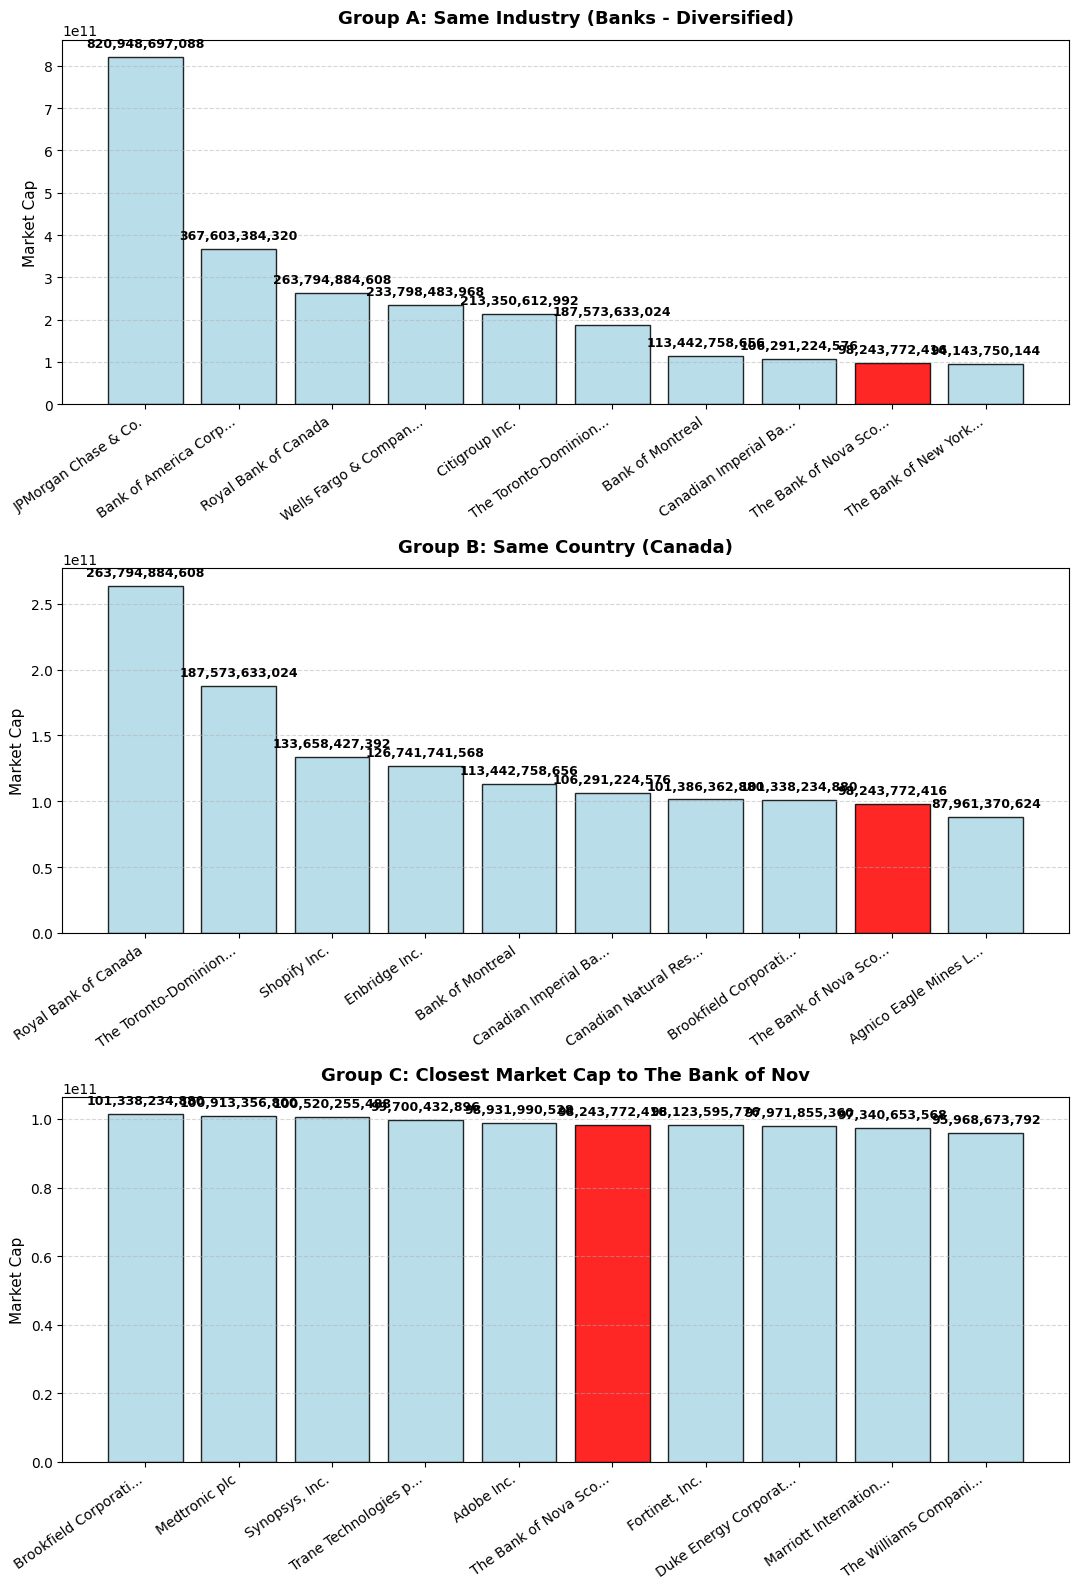

In [676]:
canada_companies = df[df['country'] == 'Canada'] 
if canada_companies.empty:
    raise ValueError("Non ci sono aziende con country='Canada' nel DataFrame!")

selected_company = canada_companies[canada_companies['company_name'] == 'The Bank of Nova Scotia'].iloc[0]

selected_name = selected_company['company_name']
sel_ind = selected_company['industry']
sel_country = selected_company['country'] 
sel_mc = selected_company['market_cap']

print(f"--- AZIENDA SELEZIONATA ---")
print(f"Nome: {selected_name} | Simbolo: {selected_company['symbol']} | Paese: {sel_country}")
print(f"Settore: {sel_ind} | Market Cap: {sel_mc:,.2f}\n")


# --- GROUP A: Same Industry ---
group_a_all = df[df['industry'] == sel_ind].sort_values(by='market_cap', ascending=False)
group_a_top10 = group_a_all.head(10)

if selected_name not in group_a_top10['company_name'].values:
    group_a = pd.concat([group_a_top10, pd.DataFrame([selected_company])])
else:
    group_a = group_a_top10
group_a = group_a.sort_values(by='market_cap', ascending=False)

# --- GROUP B: Same Country ---
group_b_all = df[df['country'] == sel_country].sort_values(by='market_cap', ascending=False)
group_b_top10 = group_b_all.head(10)

if selected_name not in group_b_top10['company_name'].values:
    group_b = pd.concat([group_b_top10, pd.DataFrame([selected_company])])
else:
    group_b = group_b_top10
group_b = group_b.sort_values(by='market_cap', ascending=False)


# --- GROUP C: Closest Market Capitalization ---
df_c = df.copy()
df_c['market_cap_diff'] = (df_c['market_cap'] - sel_mc).abs()
group_c = df_c.sort_values(by='market_cap_diff').head(10).sort_values(by='market_cap', ascending=False)


fig, axes = plt.subplots(3, 1, figsize=(11, 16))

def plot_group(ax, group_df, title):
    colors = ['red' if x == selected_name else 'lightblue' for x in group_df['company_name']]
    
    bars = ax.bar(group_df['company_name'], group_df['market_cap'], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Market Cap', fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in group_df['company_name']]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    for bar in bars:
        yval = bar.get_height()
        offset = group_df['market_cap'].max() * 0.02 
        ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f"{int(yval):,}", 
                ha='center', va='bottom', fontsize=9, fontweight='semibold')

plot_group(axes[0], group_a, f"Group A: Same Industry ({sel_ind})")
plot_group(axes[1], group_b, f"Group B: Same Country ({sel_country})")
plot_group(axes[2], group_c, f"Group C: Closest Market Cap to {selected_name[:15]}")

plt.tight_layout()
plt.show()

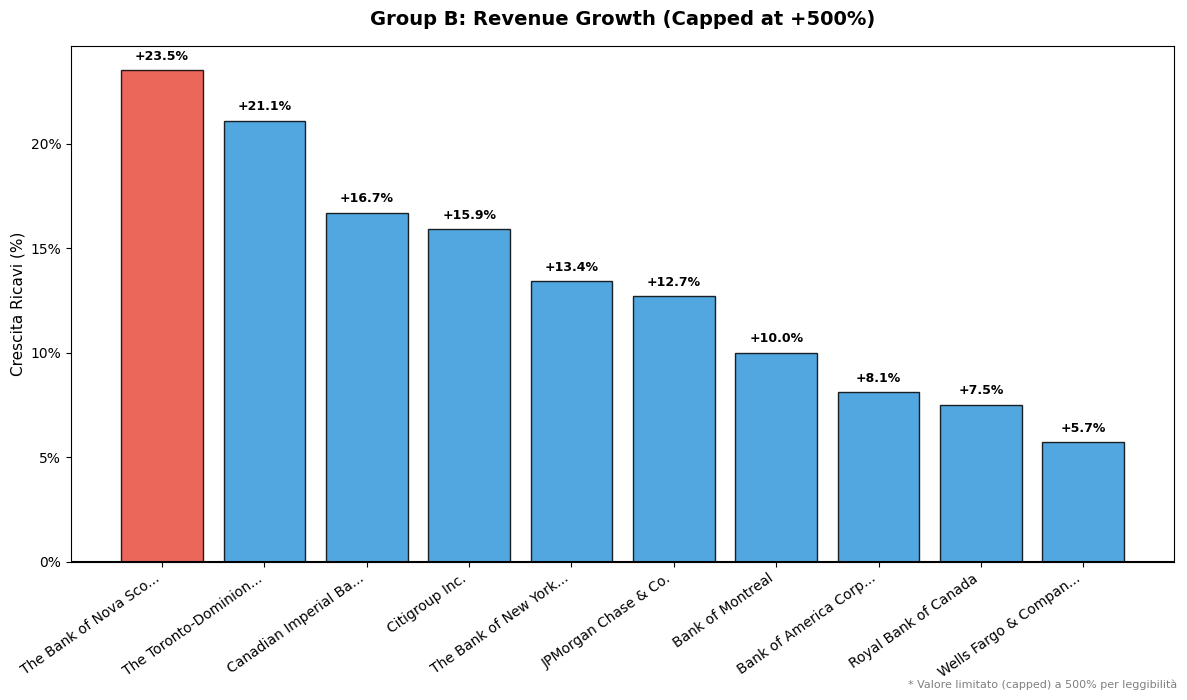

In [677]:
metric = 'revenue_growth'

cap_upper = 5.0  
cap_lower = -1.0
group_a[metric] = group_a[metric].clip(lower=cap_lower, upper=cap_upper)


valid_df = group_a.sort_values(by=metric, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

if valid_df.empty:
    ax.set_title(f"Group B: {metric}\n(Nessun dato valido)")
    ax.axis('off')
else:
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title("Group B: Revenue Growth (Capped at +500%)", fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel("Crescita Ricavi (%)", fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.axhline(0, color='black', linewidth=1.5)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.05
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        label_str = f"+{yval:.1%}" if yval > 0 else f"{yval:.1%}"
        
        if yval == cap_upper:
            label_str += "*"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9, fontweight='semibold')

    plt.figtext(0.99, 0.01, '* Valore limitato (capped) a 500% per leggibilità', 
                horizontalalignment='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

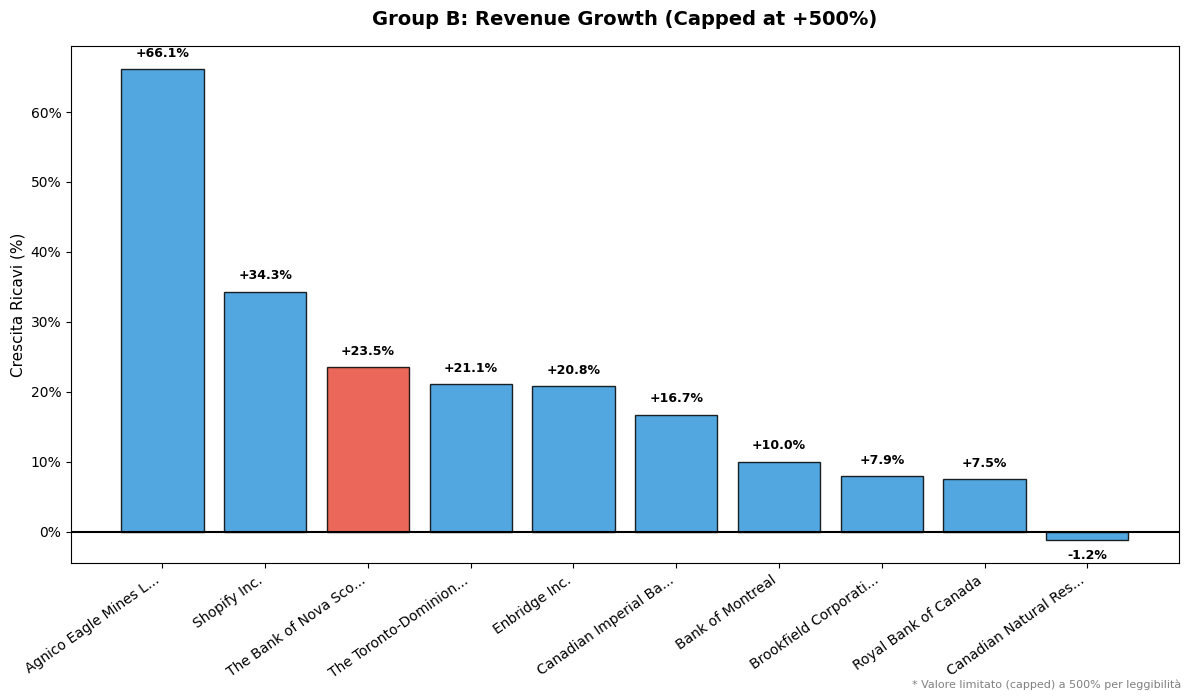

In [678]:

metric = 'revenue_growth'

cap_upper = 5.0  
cap_lower = -1.0
group_b[metric] = group_b[metric].clip(lower=cap_lower, upper=cap_upper)


valid_df = group_b.sort_values(by=metric, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

if valid_df.empty:
    ax.set_title(f"Group B: {metric}\n(Nessun dato valido)")
    ax.axis('off')
else:
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title("Group B: Revenue Growth (Capped at +500%)", fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel("Crescita Ricavi (%)", fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.axhline(0, color='black', linewidth=1.5)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.05
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        label_str = f"+{yval:.1%}" if yval > 0 else f"{yval:.1%}"
        
        if yval == cap_upper:
            label_str += "*"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9, fontweight='semibold')

    plt.figtext(0.99, 0.01, '* Valore limitato (capped) a 500% per leggibilità', 
                horizontalalignment='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

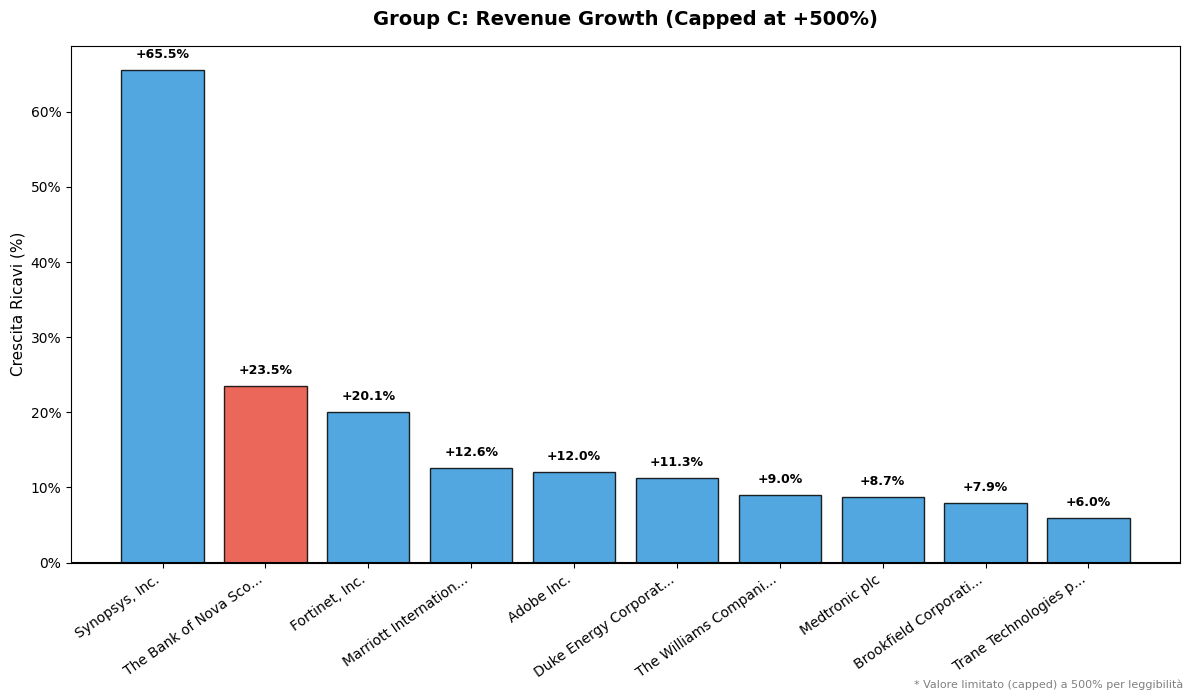

In [679]:
metric = 'revenue_growth'

cap_upper = 5.0  
cap_lower = -1.0
group_c[metric] = group_c[metric].clip(lower=cap_lower, upper=cap_upper)

valid_df = group_c.sort_values(by=metric, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

if valid_df.empty:
    ax.set_title(f"Group C: {metric}\n(Nessun dato valido)")
    ax.axis('off')
else:
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_title("Group C: Revenue Growth (Capped at +500%)", fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel("Crescita Ricavi (%)", fontsize=11)
    
    labels = [name[:20] + '...' if len(name) > 20 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.axhline(0, color='black', linewidth=1.5)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.05
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        label_str = f"+{yval:.1%}" if yval > 0 else f"{yval:.1%}"
        
        if yval == cap_upper:
            label_str += "*"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9, fontweight='semibold')

    plt.figtext(0.99, 0.01, '* Valore limitato (capped) a 500% per leggibilità', 
                horizontalalignment='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

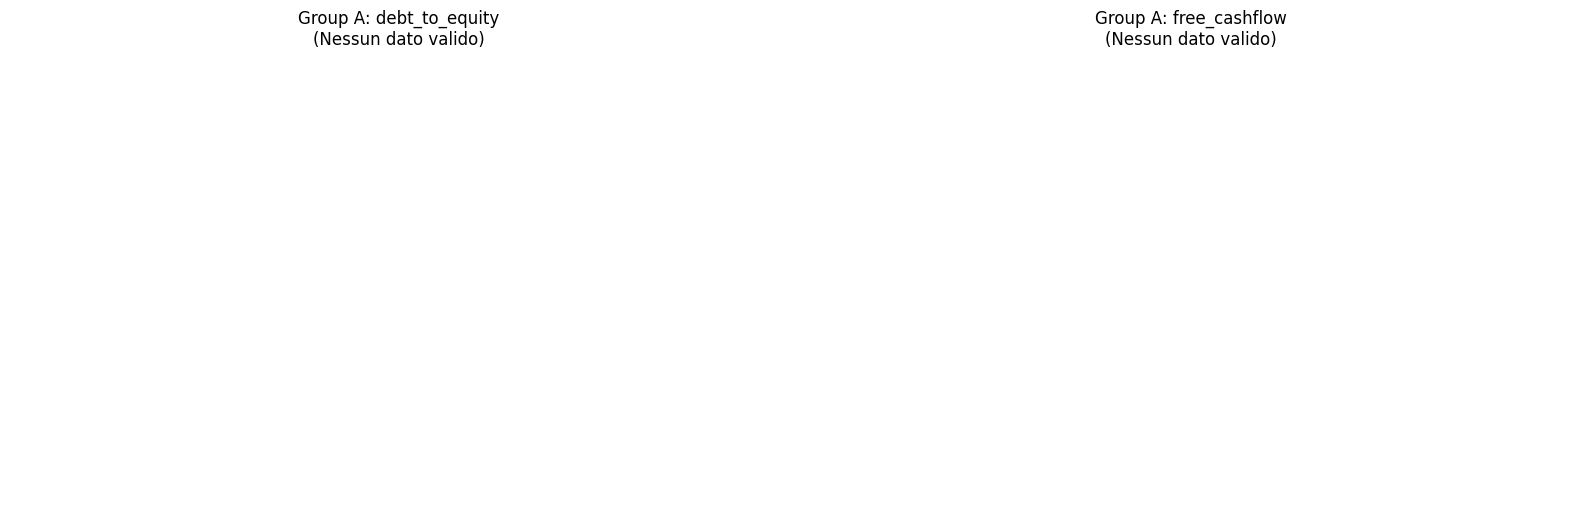

In [680]:

metrics = ['debt_to_equity', 'free_cashflow']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    valid_df = group_a.copy()
    valid_df[metric] = pd.to_numeric(valid_df[metric], errors='coerce')
    valid_df[metric] = valid_df[metric].replace([np.inf, -np.inf], np.nan)
    valid_df = valid_df.dropna(subset=[metric])
    
    if metric == 'debt_to_equity':
        # Capping degli outlier a 10,000
        cap_val = 10000
        has_outliers = (valid_df[metric] > cap_val).any()
        valid_df[metric] = valid_df[metric].clip(upper=cap_val)
    
    valid_df = valid_df.sort_values(by=metric, ascending=True)
    
    if valid_df.empty:
        ax.set_title(f"Group A: {metric}\n(Nessun dato valido)")
        ax.axis('off')
        continue
        
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    if metric == 'debt_to_equity':
        ax.set_title("Group A: Debt to Equity\n(Lower is better)", fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Debt to Equity (%)", fontsize=11)
        if has_outliers:
            ax.text(0.5, -0.4, "* Valori superiori a 10,000% sono stati cappati per leggibilità del grafico", 
                    ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray', style='italic')
    else:
        ax.set_title("Group A: Free Cashflow\n(Higher is better)", fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Free Cashflow (Assoluto)", fontsize=11)
        ax.text(0.5, -0.4, "* Un FCF negativo non è necessariamente un red flag (es. fase di forte investimento)", 
                ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray', style='italic')
    
    labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    
    ax.axhline(0, color='black', linewidth=1.2)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.5
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        if metric == 'debt_to_equity':
            label_str = f"{yval:,.0f}%"
            if yval == cap_val and has_outliers:
                label_str += "*"
        else:
            label_str = f"{yval:,.0f}"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

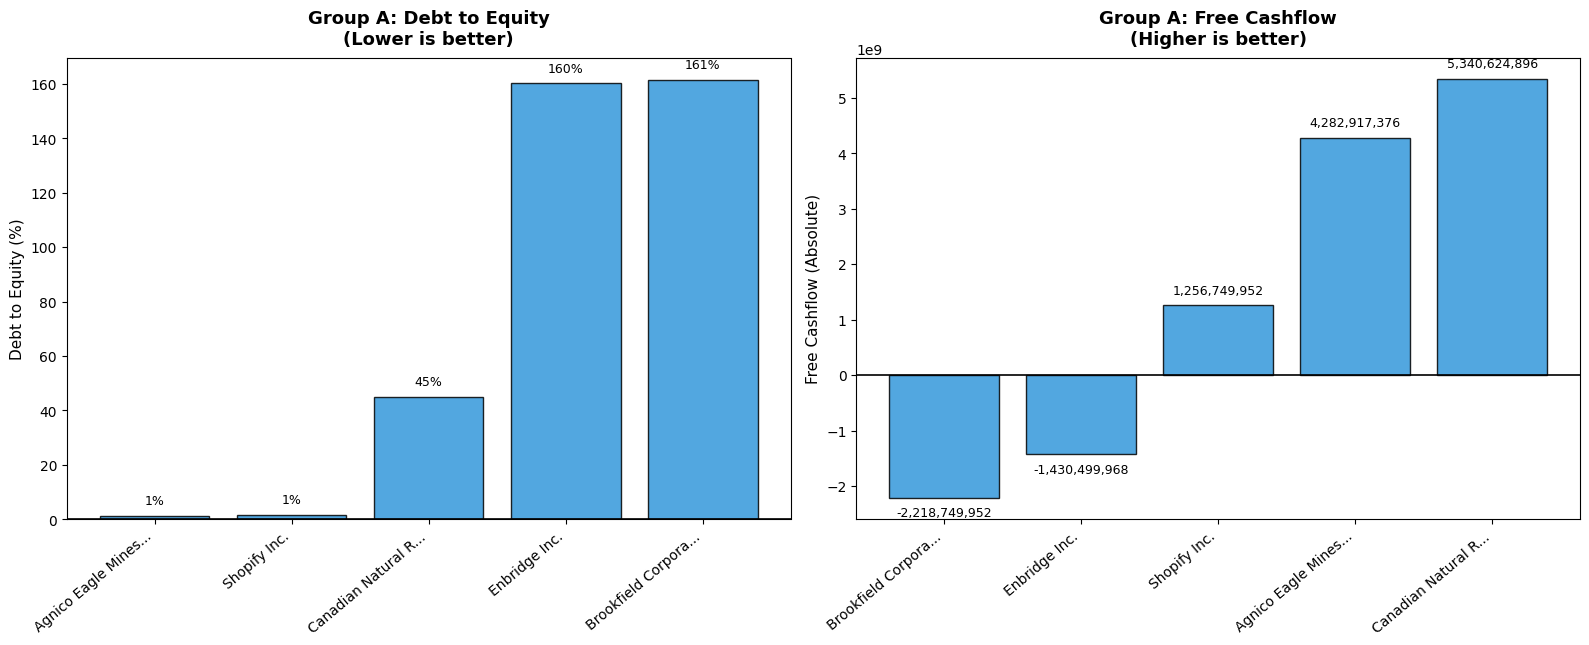

In [681]:

metrics = ['debt_to_equity', 'free_cashflow']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    valid_df = group_b.copy()
    valid_df[metric] = pd.to_numeric(valid_df[metric], errors='coerce')
    valid_df[metric] = valid_df[metric].replace([np.inf, -np.inf], np.nan)
    valid_df = valid_df.dropna(subset=[metric])
    
    if metric == 'debt_to_equity':
        cap_val = 10000
        has_outliers = (valid_df[metric] > cap_val).any()
        valid_df[metric] = valid_df[metric].clip(upper=cap_val)
    
    valid_df = valid_df.sort_values(by=metric, ascending=True)
    
    if valid_df.empty:
        ax.set_title(f"Group B: {metric}\n(Nessun dato valido)")
        ax.axis('off')
        continue
        
    company_names = valid_df['company_name'].astype(str).tolist()
    
    colors = ['#e74c3c' if name == str(selected_name) else '#3498db' for name in company_names]
    
    bars = ax.bar(company_names, valid_df[metric], color=colors, edgecolor='black', alpha=0.85)
    
    if metric == 'debt_to_equity':
        ax.set_title("Group A: Debt to Equity\n(Lower is better)", fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Debt to Equity (%)", fontsize=11)
        if has_outliers:
            ax.text(0.5, -0.4, "Values greater than 10,000% are capped ", 
                    ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray', style='italic')
    else:
        ax.set_title("Group A: Free Cashflow\n(Higher is better)", fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Free Cashflow (Absolute)", fontsize=11)
    
    labels = [name[:18] + '...' if len(name) > 18 else name for name in company_names]
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    
    ax.axhline(0, color='black', linewidth=1.2)
    
    offset = (valid_df[metric].max() - valid_df[metric].min()) * 0.02
    if pd.isna(offset) or offset == 0: 
        offset = 0.5
        
    for bar in bars:
        yval = bar.get_height()
        if pd.isna(yval):
            continue
            
        if metric == 'debt_to_equity':
            label_str = f"{yval:,.0f}%"
            if yval == cap_val and has_outliers:
                label_str += "*"
        else:
            label_str = f"{yval:,.0f}"
            
        if yval >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval + offset, label_str, 
                    ha='center', va='bottom', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, yval - offset, label_str, 
                    ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()